# Topic 16: Frequency Response Of Non-minimum Phase (NMP) and Unstable Systems

In [ ]:
# Course utilities (do not modify this cell)

from pathlib import Path
import sys

# repo_root/16_06_Class/notebooks → repo_root/16_06_Class
repo_root = Path.cwd().parents[0]
sys.path.insert(0, str(repo_root))

import courseutils.basic_material as bm
import courseutils.control_materials as cm

bm.setup_environment()
cm.setup_environment()

import numpy as np
import matplotlib.pyplot as plt
colors = bm.get_colors()

from scipy.optimize import fsolve


In [3]:
colors = bm.get_colors()

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

import control as ct
import control.matlab as cmat

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

## MP/NMP Comparison 

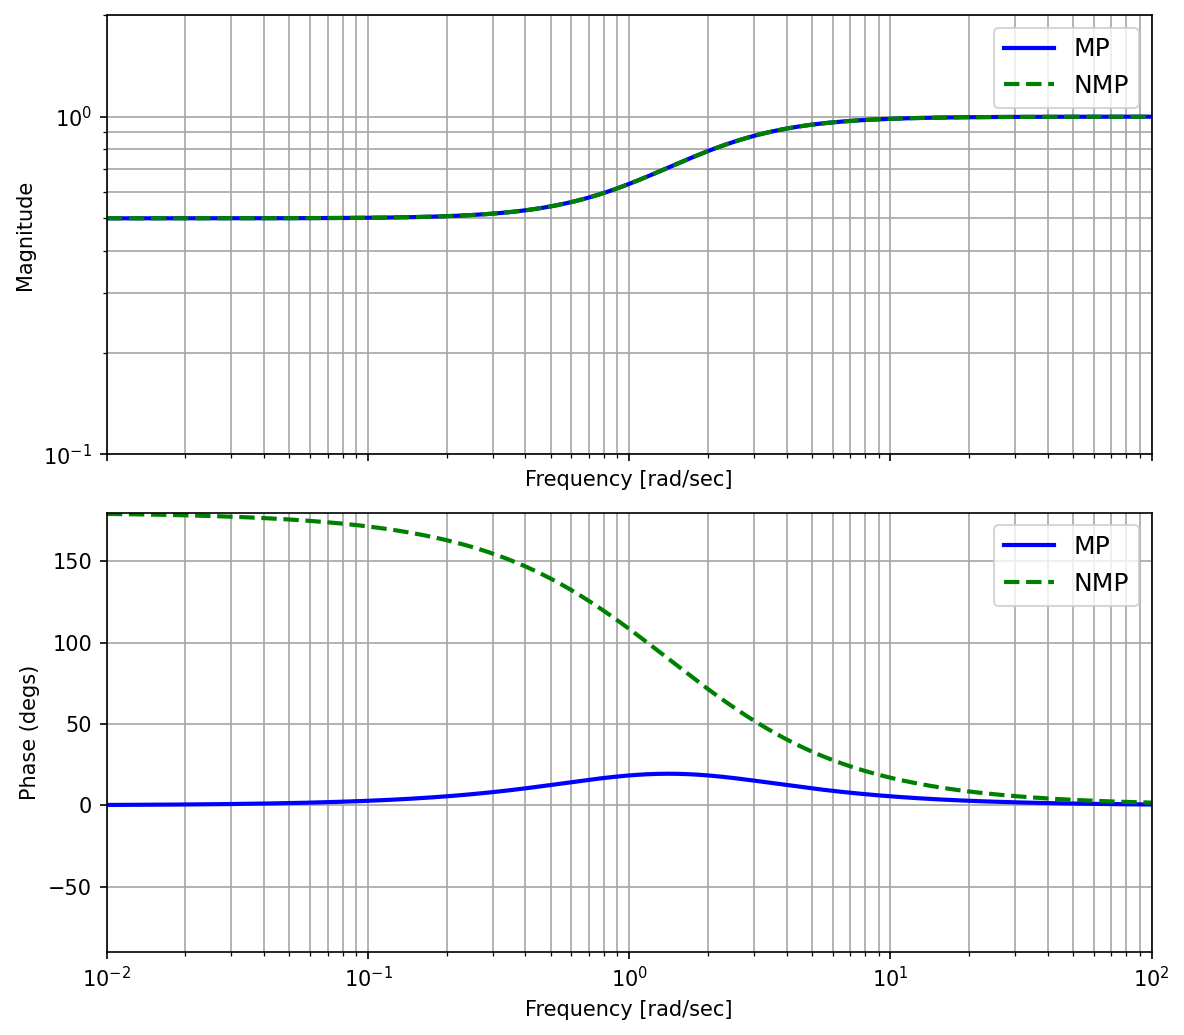

In [4]:
#NMP
w = np.logspace(-2,2,500)
Gs = (ct.tf([1,1],[1,2]),ct.tf([1,-1],[1,2]))
labels = ['MP','NMP']
colors = ['b','g']
style = ['-','--']
fig, ax = plt.subplots(2,1,figsize=(8, 7),dpi=150,sharex=True)
for kk,G in enumerate(Gs):
    [Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
    ax[0].loglog(Gw,Gm,label=labels[kk],c=colors[kk],ls=style[kk])
    ax[0].set_ylim([.1,2])
    ax[0].set_xlim([.01,100])
    ax[0].set_ylabel("Magnitude")
    ax[0].set_xlabel("Frequency [rad/sec]")
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].semilogx(Gw,cm.pshift(Gp)*cm.r2d,label=labels[kk],c=colors[kk],ls=style[kk])
    ax[1].set_ylim([-90,180])
    ax[1].set_ylabel("Phase (degs)")
    ax[1].set_xlabel("Frequency [rad/sec]")
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].legend(fontsize=12)
    ax[1].legend(fontsize=12)

plt.savefig('./figs/L14_nmp.pdf',dpi=600)
plt.show()

## Stable/Unstable Comparison

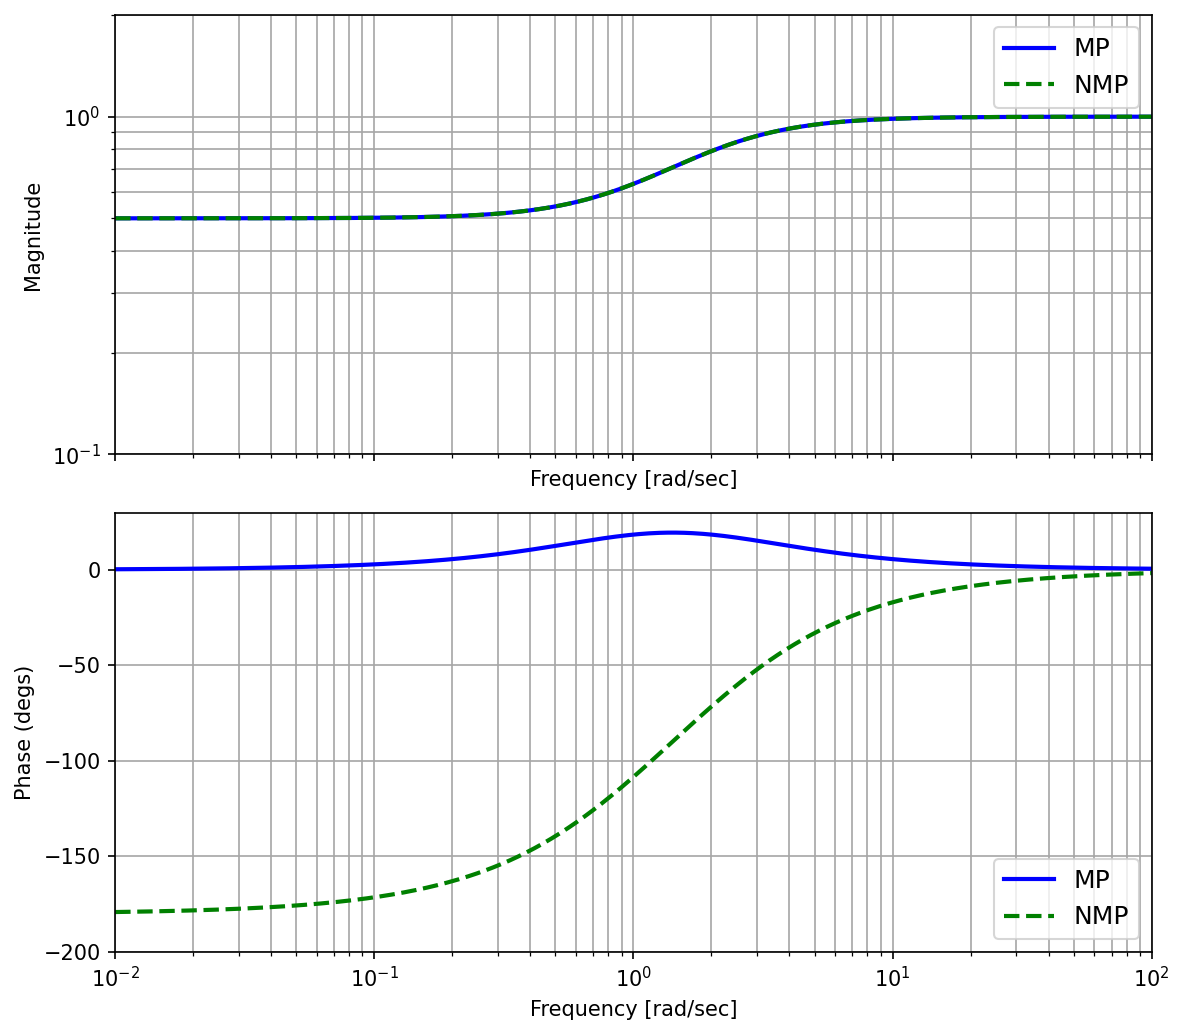

In [5]:
w = np.logspace(-2,2,500)
Gs = (ct.tf([1,1],[1,2]),ct.tf([1,1],[1,-2]))
fig, ax = plt.subplots(2,1,figsize=(8, 7),dpi=150,sharex=True)
for kk,G in enumerate(Gs):
    [Gm,Gp,Gw] = ct.frequency_response(G,omega=w)
    ax[0].loglog(Gw,Gm,label=labels[kk],c=colors[kk],ls=style[kk])
    ax[0].set_ylim([.1,2])
    ax[0].set_xlim([.01,100])
    ax[0].set_ylabel("Magnitude")
    ax[0].set_xlabel("Frequency [rad/sec]")
    ax[0].grid(True, which="both", ls="-",color='0.65')
    ax[1].semilogx(Gw,cm.pshift(Gp)*cm.r2d,label=labels[kk],c=colors[kk],ls=style[kk])
    ax[1].set_ylim([-200,30])
    ax[1].set_ylabel("Phase (degs)")
    ax[1].set_xlabel("Frequency [rad/sec]")
    ax[1].grid(True, which="both", ls="-",color='0.65')
    ax[0].legend(fontsize=12)
    ax[1].legend(fontsize=12)
    
plt.savefig('./figs/L14_uns.pdf',dpi=600)
plt.show()